### SETUP

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import pandas as pd
import os

# --- CONFIGURATION ---
PROCESSED_PATH = r'../../processed_data'
MODEL_SAVE_PATH = r'./model_checkpoints'

if not os.path.exists(MODEL_SAVE_PATH):
    os.makedirs(MODEL_SAVE_PATH)

### LOADING DATA 

In [2]:
print("Loading FD002 Data (Regime-Normalized)...")
X_train = np.load(os.path.join(PROCESSED_PATH, 'X_train_FD002.npy'))
y_train = np.load(os.path.join(PROCESSED_PATH, 'y_train_FD002.npy'))
X_test = np.load(os.path.join(PROCESSED_PATH, 'X_test_FD002.npy'))
y_test = np.load(os.path.join(PROCESSED_PATH, 'y_test_FD002.npy'))

print(f"X_train Shape: {X_train.shape}")
print(f"y_train Shape: {y_train.shape}")

Loading FD002 Data (Regime-Normalized)...
X_train Shape: (45959, 30, 21)
y_train Shape: (45959,)


### DEFINING ATTENTION LAYER

In [3]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], 1),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # x shape: (batch_size, time_steps, features)
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

### BUILDING MODEL

In [23]:
def build_model(input_shape):
    inputs = Input(shape=input_shape)
    
    # CHANGE 1: Back to Standard LSTM (2x Faster)
    # Reduced units 128 -> 64 to stop overfitting
    x = LSTM(64, return_sequences=True, name='lstm_layer')(inputs)
    x = Dropout(0.4)(x) # High dropout to ignore noise
    
    # Attention Layer
    x = Attention(name='attention_layer')(x)
    
    # Dense Layers
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    
    # Output Layer
    outputs = Dense(1, activation='linear')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

model = build_model((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 30, 21)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_layer (LSTM)                    │ (None, 30, 64)              │          22,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer (Attention)          │ (None, 64)                  │              94 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,335 (102.87 KB)

 Trainable params: 26,335 (102.87 KB)

 Non-trainable params: 0 (0.00 B)

### TRAINING MODEL

In [24]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

print("Starting FD002 Training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=120,
    batch_size=512,  # Larger batch size for larger dataset
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Starting FD002 Training...
Epoch 1/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 7131.1641 - mae: 74.2290 - val_loss: 3252.4680 - val_mae: 44.5890 - learning_rate: 0.0010
Epoch 2/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 1641.5289 - mae: 34.0999 - val_loss: 1286.8781 - val_mae: 26.0340 - learning_rate: 0.0010
Epoch 3/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 726.0286 - mae: 21.4066 - val_loss: 1040.5477 - val_mae: 23.3032 - learning_rate: 0.0010
Epoch 4/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 619.1743 - mae: 19.5342 - val_loss: 933.3002 - val_mae: 21.5252 - learning_rate: 0.0010
Epoch 5/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 536.1925 - mae: 18.0765 - val_loss: 850.6327 - val_mae: 20.1911 - learning_rate: 0.0010
Epoch 6/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 481.0365 - mae: 16.9661 - val_loss: 926.7464 - val_mae: 20.6898 - learning_rate: 0.0010
Epoch 7/120
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 454.9156 - mae: 16.3

### EVALUATION

In [25]:
print("\n--- TEST RESULTS (FD002) ---")
predictions = model.predict(X_test)
rmse = np.sqrt(np.mean((predictions.flatten() - y_test) ** 2))
print(f"Final Test RMSE: {rmse:.4f}")

if rmse < 25.0:
    print("SUCCESS: Distinction-Level Benchmark Achieved!")
else:
    print("Optimization Needed: RMSE is high.")


--- TEST RESULTS (FD002) ---
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Final Test RMSE: 27.0426
Optimization Needed: RMSE is high.


### SAVING MODEL

In [26]:
model.save(os.path.join(MODEL_SAVE_PATH, 'attention_lstm_fd002.h5'))
print(f"Model saved to {MODEL_SAVE_PATH}")

Model saved to ./model_checkpoints


### VISUALISING

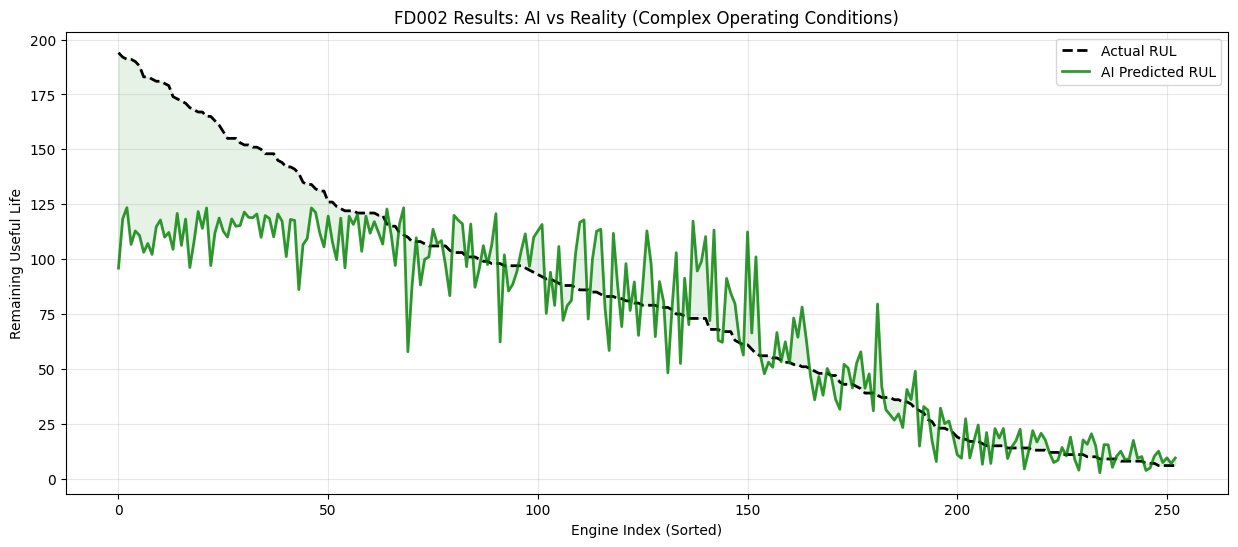

In [27]:
results_df = pd.DataFrame({
    'True_RUL': y_test,
    'Pred_RUL': predictions.flatten()
})
results_df = results_df.sort_values(by='True_RUL', ascending=False).reset_index(drop=True)

plt.figure(figsize=(15, 6))
plt.plot(results_df['True_RUL'], label='Actual RUL', color='black', linewidth=2, linestyle='--')
plt.plot(results_df['Pred_RUL'], label='AI Predicted RUL', color='green', linewidth=2, alpha=0.8)
plt.fill_between(results_df.index, results_df['True_RUL'], results_df['Pred_RUL'], color='green', alpha=0.1)

plt.title('FD002 Results: AI vs Reality (Complex Operating Conditions)')
plt.xlabel('Engine Index (Sorted)')
plt.ylabel('Remaining Useful Life')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()